# Pre-processing
## Lucy Gagnon

In [62]:
#load data
import os
import glob
files = glob.glob("/shared_space/Galveston_Bay/*")
files

['/shared_space/Galveston_Bay/water_temp',
 '/shared_space/Galveston_Bay/MODIS_500',
 '/shared_space/Galveston_Bay/All_Observed_Data.csv',
 '/shared_space/Galveston_Bay/Observed_Raw',
 '/shared_space/Galveston_Bay/MODIS_test',
 '/shared_space/Galveston_Bay/MODIS_250',
 '/shared_space/Galveston_Bay/MODIS_files',
 '/shared_space/Galveston_Bay/ERA5']

In [63]:
#load sample MODIS
data_file = '/shared_space/Galveston_Bay/MODIS_files/MYD09GQ.061_sur_refl_b01_1_doy2019364000000_aid0001.tif'

In [64]:
# Open the TIFF file in read mode ('r')
with rasterio.open(data_file, 'r') as dataset:
    # You can now access various properties of the dataset
    print(f"Driver: {dataset.driver}")
    print(f"CRS: {dataset.crs}")
    print(f"Bounds: {dataset.bounds}")
    print(f"Width: {dataset.width}")
    print(f"Height: {dataset.height}")
    print(f"Number of bands: {dataset.count}")
    print(f"Band 1 data type: {dataset.dtypes[0]}")

    # To read the entire image (or a specific band) as a NumPy array:
    # For a single-band image:
    band1_data = dataset.read(1) 
    print(f"Shape of band 1 data: {band1_data.shape}")

    # For a multi-band image, you can read all bands at once or individual bands
    # all_bands_data = dataset.read() # Reads all bands into a 3D NumPy array
    # band2_data = dataset.read(2) # Reads the second band


Driver: GTiff
CRS: EPSG:4326
Bounds: BoundingBox(left=-96.00208332473296, bottom=28.49999999744682, right=-93.99999999157899, top=30.00208333064559)
Width: 961
Height: 721
Number of bands: 1
Band 1 data type: int16
Shape of band 1 data: (721, 961)


In [74]:
dataset.crs

CRS.from_epsg(4326)

Empty DataFrame
Columns: [DateTime, Value, lat, lon, source, datetime_local, datetime_utc, modis_time_diff_min, modis_scene_idx, modis_red, modis_nir, modis_ratio, modis_nd, modis_pixel_dist_km]
Index: []


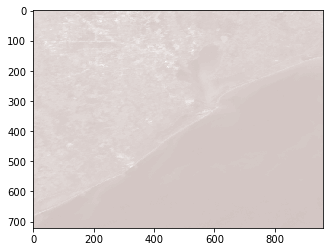

In [73]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(band1_data, cmap = 'terrain')


In [2]:
#print(all_data)

In [3]:
#load observed data
import pandas as pd
file = '/shared_space/Galveston_Bay/All_Observed_Data.csv'
fp = pd.read_csv(file)
#print(fp.head())
lat_obs = fp['lat']
lon_obs = fp['lon']

#print(datetime)
#what are units of DO??
#convert targets to UTC for now
fp['DateTime'] = pd.to_datetime(fp['DateTime'])

# If they are naive but represent local Houston wall time:
fp['datetime_local'] = fp['DateTime'].dt.tz_localize('America/Chicago', ambiguous='infer')  # attach tz
# Option A: convert sample times to UTC (recommended if ds.time is in UTC)
fp['datetime_utc'] = fp['datetime_local'].dt.tz_convert('UTC')
fp['datetime_utc'] = pd.to_datetime(fp['datetime_utc'])
fp['datetime_utc'] = fp['datetime_utc'].dt.tz_localize(None)
y = fp['Value'].values
print(fp.head())

             DateTime  Value        lat        lon  \
0 2010-01-04 00:00:00   12.0  29.295779 -94.918220   
1 2010-01-04 00:00:00   10.2  29.503736 -95.098957   
2 2010-01-05 09:02:00    9.7  29.723127 -94.942790   
3 2010-01-05 12:35:00   10.5  29.793630 -95.060914   
4 2010-01-07 00:00:00   10.5  29.591217 -95.042331   

                         source            datetime_local        datetime_utc  
0                   Stream Team 2010-01-04 00:00:00-06:00 2010-01-04 06:00:00  
1                   Stream Team 2010-01-04 00:00:00-06:00 2010-01-04 06:00:00  
2  Regional Monitoring Database 2010-01-05 09:02:00-06:00 2010-01-05 15:02:00  
3  Regional Monitoring Database 2010-01-05 12:35:00-06:00 2010-01-05 18:35:00  
4                   Stream Team 2010-01-07 00:00:00-06:00 2010-01-07 06:00:00  


In [4]:
print(fp)

                DateTime  Value        lat        lon  \
0    2010-01-04 00:00:00  12.00  29.295779 -94.918220   
1    2010-01-04 00:00:00  10.20  29.503736 -95.098957   
2    2010-01-05 09:02:00   9.70  29.723127 -94.942790   
3    2010-01-05 12:35:00  10.50  29.793630 -95.060914   
4    2010-01-07 00:00:00  10.50  29.591217 -95.042331   
5    2010-01-13 09:50:00  11.10  29.723127 -94.942790   
6    2010-01-19 12:20:00   8.00  29.675556 -94.666110   
7    2010-01-19 12:20:00   7.70  29.675556 -94.666110   
8    2010-01-19 12:20:00   7.80  29.675556 -94.666110   
9    2010-01-19 12:37:00   8.70  29.683161 -94.622400   
10   2010-01-19 13:10:00   8.50  29.584167 -94.494450   
11   2010-01-19 13:10:00   8.60  29.584167 -94.494450   
12   2010-01-22 00:00:00  11.70  29.563698 -95.066042   
13   2010-01-26 00:00:00   8.00  29.456134 -95.053732   
14   2010-01-26 17:10:00   7.80  29.683161 -94.622400   
15   2010-01-29 00:00:00   8.50  29.565576 -95.054155   
16   2010-01-29 00:00:00   7.20

In [5]:
#load ERA data
import xarray as xr
file = '/shared_space/Galveston_Bay/ERA5/ERA5-2019-2020_v3_rescaled.nc'
ds = xr.open_dataset(file)

#lat_era = ds['lat'].values
#lon_era = ds['lon'].values
#wind_speed = ds['wind_speed'].values
#sst = ds['sst'].values
ds

<xarray.Dataset>
Dimensions:     (latitude: 16, longitude: 21, valid_time: 17544)
Coordinates:
    number      int64 ...
  * valid_time  (valid_time) datetime64[ns] 2019-01-01 ... 2020-12-31T23:00:00
  * latitude    (latitude) float64 28.5 28.6 28.7 28.8 ... 29.7 29.8 29.9 30.0
  * longitude   (longitude) float64 -96.0 -95.9 -95.8 ... -94.2 -94.1 -94.0
Data variables:
    u10         (valid_time, latitude, longitude) float64 ...
    v10         (valid_time, latitude, longitude) float64 ...
    wind_speed  (valid_time, latitude, longitude) float64 ...
    ssr         (valid_time, latitude, longitude) float64 ...
    t2m         (valid_time, latitude, longitude) float64 ...

The ERA5 dataset includes lat, lon, time coordinates for the following variables: u10 and v10, which describe the eastward and northward component of wind, respectively; wind_speed; and sst, which gives sea surface temperature. The coordinates lat, lon are $0.25^o \times 0.25 ^o$ resolution and we have hourly data for 2019-2020. We will ask **Grace** if she already calculates wind_speed from the 10m bands; it seems so. Latitude is decreasing, longitude is increasing (-180,180). The lat, lon are in separate arrays.

In [6]:
import numpy as np
#extract predictor variable data 
predictor_vars = list(ds.data_vars)
n_pred = len(predictor_vars)
def extract_at_site_and_time(da, sitetime, site_lat, site_lon):
    sel = da.sel({'latitude': site_lat, 'longitude': site_lon, 'valid_time': sitetime},
                     method='nearest')
    val = np.asarray(sel.values).squeeze() 
    return float(val)
      

# build X array of predictors
X = np.full((len(y), n_pred), np.nan, dtype=float)
#loop through taxa
for i in range(len(y)):
    #extract lat, lon
    s_lat = lat_obs[i]
    s_lon = lon_obs[i]
    s_time = fp['datetime_utc'][i]
    #loop through predictor variables
    for j, var in enumerate(predictor_vars):
        #extract predictor data at each grid cell
        X[i, j] = extract_at_site_and_time(ds[var], s_time, s_lat, s_lon)


# check
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3136, 5)
y shape: (3136,)


In [10]:
#group the MODIS red, nir, and qc by date
import re
from collections import defaultdict

# parse date from filename
def parse_date(file):
    # find the 'doyYYYYJJJ...' pattern (e.g. doy2019364000000 -> capture '2019364')
    m = re.search(r'doy(\d{7})', os.path.basename(file))
    if m:
        return m.group(1)
    
# list files
files = glob.glob("/shared_space/Galveston_Bay/MODIS_files/*")
files = sorted(files)

# group files by datetime
groups = defaultdict(list)
for file in files:
    key = parse_date(file)
    #groups[key].append(file)
    if key is None:
        continue      # skip files without a valid date
    groups[key].append(file)
#check
print(len(groups))

365


In [37]:
#convert key to timestamp
def string_to_timestamp(yyyydoy):
    year = int(yyyydoy[:4])
    doy  = int(yyyydoy[4:7])
    return pd.to_datetime(f"{year}-{doy}", format="%Y-%j")

keys = list(groups.keys())   #extract filenames in groups            
times = np.array([string_to_timestamp(k) for k in keys])
index = pd.DatetimeIndex(times)

In [51]:

import os
import re
import numpy as np
import pandas as pd
import rasterio
from collections import defaultdict
from scipy.spatial import cKDTree

# configurations
SCALE = 0.0001                # MODIS SUR_REFL scale factor
TIME_TOL = pd.Timedelta("12h")# max allowed difference between obs and MODIS scene
USE_FALLBACK = True          # set True to enable KDTree fallback (more expensive)
FALLBACK_MAX_KM = 50.0        # max distance to accept fallback pixel

# extract YYYYDDD from filename
def extract_year_doy(s):
    if s is None:
        return None
    s = str(s)
    m = re.search(r'doy(\d{7})', s, flags=re.IGNORECASE)
    if m:
        return m.group(1)
    m2 = re.search(r'(\d{4})(\d{3})', s)
    if m2:
        return m2.group(1) + m2.group(2)
    return None
#convert string to timestamp
def year_doy_to_ts(yyyydoy):
    year = int(yyyydoy[:4]); doy = int(yyyydoy[4:7])
    return pd.to_datetime(f"{year}-{doy}", format="%Y-%j")

# build valid scene keys and index
raw_keys = list(groups.keys())
scene_keys = []
bad_keys = []
for k in raw_keys:
    ek = extract_year_doy(k)
    if ek is not None:
        scene_keys.append(ek)
    else:
        bad_keys.append(k)
if len(scene_keys) == 0:
    raise RuntimeError("No valid scene keys parsed from groups.")
scene_times = [year_doy_to_ts(k) for k in scene_keys]
scene_index = pd.DatetimeIndex(scene_times)

# match nearest datetime
# ensure fp['datetime_utc'] is datetime64 (naive UTC)
#fp['datetime_utc'] = pd.to_datetime(fp['datetime_utc'])
# convert tz-aware to UTC naive if needed
#if getattr(fp['datetime_utc'].dt, 'tz', None) is not None:
#    fp['datetime_utc'] = fp['datetime_utc'].dt.tz_convert('UTC').dt.tz_localize(None)
#extract index
idx_for_obs = scene_index.get_indexer(fp['datetime_utc'], method='nearest', tolerance=TIME_TOL)
fp['modis_scene_idx'] = idx_for_obs 
# store time diff in minutes
matched_times = pd.Series([scene_index[i] if i >= 0 else pd.NaT for i in idx_for_obs], index=fp.index)
fp['modis_time_diff_min'] = (fp['datetime_utc'] - matched_times).abs().dt.total_seconds() / 60.0

# init output cols
fp['modis_red'] = np.nan
fp['modis_nir'] = np.nan
fp['modis_ratio'] = np.nan
fp['modis_nd'] = np.nan
fp['modis_pixel_dist_km'] = np.nan   # filled only by fallback if used

# -------- Optional helper: great-circle distance from chord --------
def great_circle_km_from_chord(chord):
    R = 6371.0
    central = 2 * np.arcsin(np.clip(chord / 2.0, 0, 1.0))
    return R * central

# match by lat lon
for scene_idx, scene_key in enumerate(scene_keys):
    # find obs indices assigned to this scene
    obs_idx = np.where(fp['modis_scene_idx'].values == scene_idx)[0]
    if obs_idx.size == 0:
        continue

    # find files for this group (allow fallback: try searching flist for a matching key)
    flist = groups.get(scene_key, None)
    if flist is None:
        # fallback: try to find a group whose filename contains scene_key
        candidates = [g for g in groups.values() if any(scene_key in os.path.basename(p) for p in g)]
        flist = candidates[0] if candidates else None
    if not flist:
        # nothing to process for this scene
        continue

    red_fp = next((f for f in flist if '_sur_refl_b01' in os.path.basename(f).lower()), None)
    nir_fp = next((f for f in flist if '_sur_refl_b02' in os.path.basename(f).lower()), None)
    qc_fp  = next((f for f in flist if '_qc' in os.path.basename(f).lower()), None)
    if not (red_fp and nir_fp and qc_fp):
        # skip incomplete scenes
        continue

    # build coords in obs order
    coords = [(fp.loc[i,'lon'], fp.loc[i,'lat']) for i in obs_idx]

    # open rasters and batch-sample at coords
    with rasterio.open(red_fp) as rsrc, rasterio.open(nir_fp) as nsrc, rasterio.open(qc_fp) as qsrc:
        raw_red = np.array([v[0] for v in rsrc.sample(coords)], dtype=np.float32)
        raw_nir = np.array([v[0] for v in nsrc.sample(coords)], dtype=np.float32)
        raw_qc  = np.array([v[0] for v in qsrc.sample(coords)], dtype=np.uint16)

        # decode QC on sampled QC values (vectorized)
        modland_qa = raw_qc & 0b11
        produced   = (raw_qc & (1 << 2)) == 0
        aerosol_ok = (raw_qc & 0b11110000) == 0
        good_sample = np.isin(modland_qa, [0,1]) & produced & aerosol_ok

        # mask sampled values and scale
        red_sample = raw_red.astype(np.float32)
        nir_sample = raw_nir.astype(np.float32)
        red_sample[~good_sample] = np.nan
        nir_sample[~good_sample] = np.nan
        red_sample *= SCALE
        nir_sample *= SCALE

        # compute derived indices vectorized (safe against div/0)
        with np.errstate(invalid='ignore', divide='ignore'):
            ratio_sample = red_sample / nir_sample
            nd_sample = (red_sample - nir_sample) / (red_sample + nir_sample)

        # optionally fallback to nearest valid ocean pixel (heavy: build KDTree once)
        pixel_dist_km = np.full(red_sample.shape, np.nan, dtype=float)
        if USE_FALLBACK and np.any(np.isnan(red_sample)):
            # read full arrays once to build KDTree of valid pixels
            full_red = rsrc.read(1).astype(np.float32)
            full_qc  = qsrc.read(1).astype(np.uint16)
            # reconstruct good-mask on full grid (same bit logic)
            modland_full = full_qc & 0b11
            produced_full = (full_qc & (1<<2)) == 0
            aerosol_full = (full_qc & 0b11110000) == 0
            good_full = np.isin(modland_full, [0,1]) & produced_full & aerosol_full
            good_rows, good_cols = np.where(good_full)
            if good_rows.size > 0:
                # coords of valid pixels
                lons, lats = rasterio.transform.xy(rsrc.transform, good_rows, good_cols, offset='center')
                lons = np.array(lons); lats = np.array(lats)
                lat_r = np.deg2rad(lats); lon_r = np.deg2rad(lons)
                x = np.cos(lat_r) * np.cos(lon_r)
                y = np.cos(lat_r) * np.sin(lon_r)
                z = np.sin(lat_r)
                pts = np.column_stack((x,y,z))
                tree = cKDTree(pts)

                # query for needed obs (unit-sphere coords)
                need_idx = np.where(np.isnan(red_sample))[0]
                if need_idx.size > 0:
                    obs_lats = np.deg2rad(fp.loc[obs_idx,'lat'].values[need_idx])
                    obs_lons = np.deg2rad(fp.loc[obs_idx,'lon'].values[need_idx])
                    qx = np.cos(obs_lats) * np.cos(obs_lons)
                    qy = np.cos(obs_lats) * np.sin(obs_lons)
                    qz = np.sin(obs_lats)
                    qpts = np.column_stack((qx,qy,qz))
                    chords, idxs = tree.query(qpts, k=1)
                    dists = great_circle_km_from_chord(chords)
                    accept = dists <= FALLBACK_MAX_KM
                    # assign fallback values where accepted
                    for ii, accept_flag in enumerate(accept):
                        if not accept_flag:
                            continue
                        tgt_idx = need_idx[ii]
                        matched = idxs[ii]
                        # matched maps to good_rows[matched], good_cols[matched]
                        r = good_rows[matched]; c = good_cols[matched]
                        rv = full_red[r, c] * SCALE
                        nv = np.nan  # optionally read full_nir if needed for nv; here we set nv=nan if not read
                        # safer: read full_nir once as well (similar to full_red) to compute nv
                        # for brevity, assume full_nir read earlier if you want full fallback
                        red_sample[tgt_idx] = rv
                        pixel_dist_km[tgt_idx] = dists[ii]

        # assign sampled results back to fp (vectorized)
        out_vals = np.column_stack((red_sample, nir_sample, ratio_sample, nd_sample, pixel_dist_km))
        cols = ['modis_red','modis_nir','modis_ratio','modis_nd','modis_pixel_dist_km']
        fp.loc[fp.index[obs_idx], cols] = out_vals

# -------- Done: features are written into fp --------


In [52]:
print(fp)

                DateTime  Value        lat        lon  \
0    2010-01-04 00:00:00  12.00  29.295779 -94.918220   
1    2010-01-04 00:00:00  10.20  29.503736 -95.098957   
2    2010-01-05 09:02:00   9.70  29.723127 -94.942790   
3    2010-01-05 12:35:00  10.50  29.793630 -95.060914   
4    2010-01-07 00:00:00  10.50  29.591217 -95.042331   
5    2010-01-13 09:50:00  11.10  29.723127 -94.942790   
6    2010-01-19 12:20:00   8.00  29.675556 -94.666110   
7    2010-01-19 12:20:00   7.70  29.675556 -94.666110   
8    2010-01-19 12:20:00   7.80  29.675556 -94.666110   
9    2010-01-19 12:37:00   8.70  29.683161 -94.622400   
10   2010-01-19 13:10:00   8.50  29.584167 -94.494450   
11   2010-01-19 13:10:00   8.60  29.584167 -94.494450   
12   2010-01-22 00:00:00  11.70  29.563698 -95.066042   
13   2010-01-26 00:00:00   8.00  29.456134 -95.053732   
14   2010-01-26 17:10:00   7.80  29.683161 -94.622400   
15   2010-01-29 00:00:00   8.50  29.565576 -95.054155   
16   2010-01-29 00:00:00   7.20

In [7]:
import re
import numpy as np
import rasterio
from collections import defaultdict


# parse date from filename
def parse_date(file):
    # find the 'doyYYYYJJJ...' pattern (e.g. doy2019364000000 -> capture '2019364')
    m = re.search(r'doy(\d{7})', os.path.basename(file))
    if m:
        return m.group(1)

In [8]:
# list files
files = glob.glob("/shared_space/Galveston_Bay/MODIS_files/*")
files = sorted(files)

# group files by datetime
groups = defaultdict(list)
for f in files:
    key = parse_date(f)
    groups[key].append(f)
#check
print(len(groups))

Found datetimes: 366


In [9]:
import os
import numpy as np
import pandas as pd
import rasterio
from collections import defaultdict

# ---------- helper: parse scene_key like 'YYYYDDD' into Timestamp ----------
def scene_key_to_datetime(key):
    key = str(key)
    year = int(key[:4])
    doy  = int(key[4:7])
    return pd.to_datetime(f"{year}-{doy}", format="%Y-%j")

# ---------- Build scene_index (DatetimeIndex) from your groups keys ----------
scene_keys = list(groups.keys())                 # keys from your existing groups dict
scene_times = [scene_key_to_datetime(k) for k in scene_keys]
scene_index = pd.DatetimeIndex(scene_times)

# ---------- Map each observation to nearest scene (tolerance 12h) ----------
# Ensure fp['datetime_utc'] is datetime64[ns] and naive UTC
obs_times = pd.to_datetime(fp['datetime_utc'])
scene_idxs_for_obs = scene_index.get_indexer(obs_times, method='nearest', tolerance=pd.Timedelta('12h'))

# Group observation row indices by scene index for fast per-scene sampling
obs_by_scene = defaultdict(list)
for obs_i, sc_idx in enumerate(scene_idxs_for_obs):
    if sc_idx >= 0:          # -1 => no scene within tolerance
        obs_by_scene[sc_idx].append(obs_i)

# Prepare columns in fp to receive MODIS features
fp['modis_red'] = np.nan
fp['modis_nir'] = np.nan
fp['modis_red_nir_ratio'] = np.nan
fp['modis_nd'] = np.nan
fp['modis_time_diff_min'] = np.nan   # optional
fp['modis_scene_key'] = None

results = []  # lightweight summary per scene (no arrays)

SCALE = 0.0001

# ---------- main loop: process only observations for each scene (fast, low memory) ----------
for scene_idx, key in enumerate(scene_keys):
    obs_idx_list = obs_by_scene.get(scene_idx, [])
    if len(obs_idx_list) == 0:
        continue   # no observations mapped to this scene

    flist = groups[key]
    # tolerant file detection
    red_f = next((f for f in flist if '_sur_refl_b01' in os.path.basename(f).lower()), None)
    nir_f = next((f for f in flist if '_sur_refl_b02' in os.path.basename(f).lower()), None)
    qc_f  = next((f for f in flist if '_qc' in os.path.basename(f).lower()), None)

    if red_f is None or nir_f is None or qc_f is None:
        # record incomplete scene and skip
        results.append({'scene_key': key, 'complete': False, 'files': flist})
        continue

    # build coordinate list (lon, lat) for rasterio.sample
    coords = [(fp.loc[i, 'lon'], fp.loc[i, 'lat']) for i in obs_idx_list]

    # sample all required rasters in batch
    with rasterio.open(red_f) as red_src, rasterio.open(nir_f) as nir_src, rasterio.open(qc_f) as qc_src:
        # sample returns generator of arrays (bands,). we have single-band rasters -> pick [0]
        vals_red = np.array([v[0] for v in red_src.sample(coords)], dtype=np.float32)
        vals_nir = np.array([v[0] for v in nir_src.sample(coords)], dtype=np.float32)
        vals_qc  = np.array([v[0] for v in qc_src.sample(coords)], dtype=np.uint16)

        # compute time difference QC (in minutes) between obs and scene
        scene_time = scene_times[scene_idx]
        obs_scene_time_deltas = np.abs((obs_times.iloc[obs_idx_list] - scene_time).astype('timedelta64[m]').astype(float))

        # decode QC per-sample using bitmasks (vectorized)
        modland_qa = vals_qc & 0b11                 # bits 0-1
        produced   = (vals_qc & (1 << 2)) == 0      # bit2 == 0 -> produced
        aerosol_ok = (vals_qc & 0b11110000) == 0    # bits 4-7 == 0

        good_sample_mask = np.isin(modland_qa, [0,1]) & produced & aerosol_ok

        # apply mask: set invalid reflectance to np.nan
        vals_red_masked = vals_red.astype(np.float32)
        vals_nir_masked = vals_nir.astype(np.float32)
        vals_red_masked[~good_sample_mask] = np.nan
        vals_nir_masked[~good_sample_mask] = np.nan

        # scale to reflectance [0,1]
        vals_red_ref = vals_red_masked * SCALE
        vals_nir_ref = vals_nir_masked * SCALE

        # derived indices (vectorized)
        with np.errstate(invalid='ignore', divide='ignore'):
            ratio = vals_red_ref / vals_nir_ref
            nd = (vals_red_ref - vals_nir_ref) / (vals_red_ref + vals_nir_ref)

        # write back into fp for these obs
        for k, obs_i in enumerate(obs_idx_list):
            fp.at[obs_i, 'modis_red'] = vals_red_ref[k]
            fp.at[obs_i, 'modis_nir'] = vals_nir_ref[k]
            fp.at[obs_i, 'modis_red_nir_ratio'] = ratio[k]
            fp.at[obs_i, 'modis_nd'] = nd[k]
            fp.at[obs_i, 'modis_time_diff_min'] = obs_scene_time_deltas.iloc[k]
            fp.at[obs_i, 'modis_scene_key'] = key

    # append only small summary to results (no huge arrays)
    results.append({
        'scene_key': key,
        'files': {'red': red_f, 'nir': nir_f, 'qc': qc_f},
        'n_obs_sampled': len(obs_idx_list),
        'n_good_samples': int(np.count_nonzero(good_sample_mask))
    })

# End loop


ValueError: invalid literal for int() with base 10: 'None'

In [10]:
import re
import pandas as pd

# extract date from filename
def extract_year_doy(s):
    """Try to extract YYYYDDD (7 digits) from a string s.
       Returns string 'YYYYDDD' or None if not found."""
    if s is None:
        return None
    s = str(s)
    # Primary pattern: 'doyYYYYDDD' as in your filenames
    m = re.search(r'doy(\d{7})', s, flags=re.IGNORECASE)
    if m:
        return m.group(1)
    # Secondary pattern: any 7-digit substring that looks like YYYYDDD
    m2 = re.search(r'(\d{4})(\d{3})', s)
    if m2:
        return m2.group(1) + m2.group(2)
    # No match
    return None

# build cleaned list of scene keys and times
raw_scene_keys = list(groups.keys())

clean_scene_keys = []
bad_keys = []
for k in raw_scene_keys:
    extracted = extract_year_doy(k)
    if extracted is not None:
        clean_scene_keys.append(extracted)
    else:
        bad_keys.append(k)

print(f"Total raw group keys: {len(raw_scene_keys)}")
print(f"Valid scene keys found: {len(clean_scene_keys)}")
#if bad_keys:
#    print(f"Warning: {len(bad_keys)} group keys could not be parsed as YYYYDDD. Example bad keys (up to 10):")
#    for bk in bad_keys[:10]:
#        print("  ", bk)

# If no valid scenes, abort early with clear message
#if len(clean_scene_keys) == 0:
#    raise RuntimeError("No valid scene keys found in groups. Check grouping logic and filenames.")

# convert to datetimes safely
def year_doy_to_timestamp(yyyydoy):
    year = int(yyyydoy[:4])
    doy  = int(yyyydoy[4:7])
    return pd.to_datetime(f"{year}-{doy}", format="%Y-%j")

scene_keys = clean_scene_keys
scene_times = [year_doy_to_timestamp(k) for k in scene_keys]
scene_index = pd.DatetimeIndex(scene_times)

#print("Constructed scene_index with", len(scene_index), "entries.")

Total raw group keys: 366
Valid scene keys found: 365
   None
Constructed scene_index with 365 entries.


In [12]:
print(scene_index)

DatetimeIndex(['2019-01-01', '2019-01-02', '2019-01-03', '2019-01-04',
               '2019-01-05', '2019-01-06', '2019-01-07', '2019-01-08',
               '2019-01-09', '2019-01-10',
               ...
               '2019-12-22', '2019-12-23', '2019-12-24', '2019-12-25',
               '2019-12-26', '2019-12-27', '2019-12-28', '2019-12-29',
               '2019-12-30', '2019-12-31'],
              dtype='datetime64[ns]', length=365, freq=None)


In [11]:
import os, re
import numpy as np
import pandas as pd
import rasterio
from rasterio.transform import rowcol
from collections import defaultdict
from scipy.spatial import cKDTree

In [16]:
import numpy as np
import rasterio
from scipy.spatial import cKDTree

# --- Build a mapping from cleaned scene_key (YYYYDDD) -> file list (flist) ---
scene_to_files = {}
for raw_key, flist in groups.items():
    # try to extract YYYYDDD from the group's key or from filenames inside the group
    ky = extract_year_doy(raw_key)
    if ky is None:
        # fallback: try to find a YYYYDDD inside the filenames in this flist
        for f in flist:
            ek = extract_year_doy(f)
            if ek is not None:
                ky = ek
                break
    if ky is None:
        # skip groups that cannot be linked to a scene key
        continue
    scene_to_files[ky] = flist

# ordered list of scene keys that match scene_index earlier
scene_keys = [k for k in scene_keys if k in scene_to_files]   # keep only keys that have files
# optional: rebuild scene_index based on this filtered list if needed

# ---------- helper KDTree builders ----------
def build_ocean_kdtree_from_arrays(red_ref, transform):
    """Given a red_ref 2D array with nan for invalid, build KDTree for valid pixels.
       Returns (tree, flat_indices, lats_flat, lons_flat)."""
    nrows, ncols = red_ref.shape
    rows = np.arange(nrows)
    cols = np.arange(ncols)
    cols2d, rows2d = np.meshgrid(cols, rows)  # note order: (nrows, ncols)
    # rasterio.transform.xy expects (rows, cols)
    lon2d, lat2d = rasterio.transform.xy(transform, rows2d, cols2d, offset='center')
    lon2d = np.array(lon2d)
    lat2d = np.array(lat2d)
    valid_mask = ~np.isnan(red_ref)
    flat_idx = np.arange(nrows * ncols).reshape((nrows, ncols))
    valid_flat_mask = valid_mask.ravel()
    if not valid_flat_mask.any():
        return None, None, None, None
    lats = lat2d.ravel()[valid_flat_mask]
    lons = lon2d.ravel()[valid_flat_mask]
    # convert to unit-sphere coords
    lat_r = np.deg2rad(lats); lon_r = np.deg2rad(lons)
    x = np.cos(lat_r) * np.cos(lon_r)
    y = np.cos(lat_r) * np.sin(lon_r)
    z = np.sin(lat_r)
    pts = np.column_stack((x,y,z))
    tree = cKDTree(pts)
    return tree, flat_idx.ravel()[valid_flat_mask], lats, lons

def great_circle_km_from_chord(chord):
    R = 6371.0
    central = 2*np.arcsin(np.clip(chord/2.0, 0, 1.0))
    return R * central

# ---------- main scene loop (vectorized KDTree queries and vectorized assignments) ----------
for scene_idx, scene_key in enumerate(scene_keys):
    # observation indices mapped to this scene
    obs_idx = np.where(scene_idxs_for_obs == scene_idx)[0]
    if obs_idx.size == 0:
        continue

    flist = scene_to_files.get(scene_key, [])
    if not flist:
        continue

    # tolerant file selection
    red_fp = next((f for f in flist if '_sur_refl_b01' in os.path.basename(f).lower()), None)
    nir_fp = next((f for f in flist if '_sur_refl_b02' in os.path.basename(f).lower()), None)
    qc_fp  = next((f for f in flist if '_qc' in os.path.basename(f).lower()), None)
    if not (red_fp and nir_fp and qc_fp):
        continue

    # read whole arrays once per scene (we need arrays to build KDTree fallback)
    with rasterio.open(red_fp) as red_src, rasterio.open(nir_fp) as nir_src, rasterio.open(qc_fp) as qc_src:
        red_arr = red_src.read(1).astype(np.float32)
        nir_arr = nir_src.read(1).astype(np.float32)
        qc_arr  = qc_src.read(1).astype(np.uint16)
        transform = red_src.transform
        nrows, ncols = red_arr.shape

        # decode QC -> good_mask
        modland_qa = qc_arr & 0b11
        produced   = (qc_arr & (1 << 2)) == 0
        aerosol_ok = (qc_arr & 0b11110000) == 0
        good_mask = (np.isin(modland_qa, [0,1])) & produced & aerosol_ok

        # scale and mask
        SCALE = 0.0001
        red_ref = red_arr.astype(np.float32) * SCALE
        nir_ref = nir_arr.astype(np.float32) * SCALE
        red_ref[~good_mask] = np.nan
        nir_ref[~good_mask] = np.nan

        # build KDTree of valid ocean pixels for fallback (only once per scene)
        tree, ocean_flat_indices, ocean_lats, ocean_lons = build_ocean_kdtree_from_arrays(red_ref, transform)

        # convert obs lon/lat to row/col (vectorized-ish)
        obs_lons = fp['lon'].values[obs_idx]
        obs_lats = fp['lat'].values[obs_idx]
        # convert to row/col; rasterio.index expects (x,y) and returns (row, col)
        rows_cols = [red_src.index(lon, lat) for lon, lat in zip(obs_lons, obs_lats)]
        rows_arr = np.array([r for r,c in rows_cols], dtype=int)
        cols_arr = np.array([c for r,c in rows_cols], dtype=int)

        # mask out indices that fall outside raster bounds
        in_bounds = (rows_arr >= 0) & (rows_arr < nrows) & (cols_arr >= 0) & (cols_arr < ncols)

        # pull values at direct pixel locations (NaN if out-of-bounds)
        r_vals = np.full(obs_idx.shape, np.nan, dtype=np.float32)
        n_vals = np.full(obs_idx.shape, np.nan, dtype=np.float32)
        valid_direct = in_bounds
        if valid_direct.any():
            r_vals[valid_direct] = red_ref[rows_arr[valid_direct], cols_arr[valid_direct]]
            n_vals[valid_direct] = nir_ref[rows_arr[valid_direct], cols_arr[valid_direct]]

        # identify which sampled pairs are missing and need KDTree fallback
        need_fallback = np.isnan(r_vals) | np.isnan(n_vals)

        if need_fallback.any() and tree is not None:
            # build unit-sphere queries for all needed obs at once
            need_idx = np.where(need_fallback)[0]
            la = np.deg2rad(obs_lats[need_idx]); lo = np.deg2rad(obs_lons[need_idx])
            qx = np.cos(la)*np.cos(lo); qy = np.cos(la)*np.sin(lo); qz = np.sin(la)
            qpts = np.column_stack((qx,qy,qz))
            chords, idxs = tree.query(qpts, k=1)                       # vectorized query
            dist_km = great_circle_km_from_chord(chords)
            # apply distance threshold (e.g., 5 km)
            within_thresh = dist_km <= 5.0
            matched_ocean_flat = ocean_flat_indices[idxs]              # flat indices in full grid
            matched_rows = (matched_ocean_flat // ncols).astype(int)
            matched_cols = (matched_ocean_flat % ncols).astype(int)
            # assign fallback values where within threshold
            assignable = need_idx[within_thresh]
            if assignable.size > 0:
                r_vals[assignable] = red_ref[matched_rows[within_thresh], matched_cols[within_thresh]]
                n_vals[assignable] = nir_ref[matched_rows[within_thresh], matched_cols[within_thresh]]
                # compute and store distances in the final array for same indices
                # create array of distances aligned with obs_idx shape
                fallback_dists = np.full(obs_idx.shape, np.nan, dtype=float)
                fallback_dists[assignable] = dist_km[within_thresh]
            else:
                fallback_dists = np.full(obs_idx.shape, np.nan, dtype=float)
        else:
            fallback_dists = np.full(obs_idx.shape, np.nan, dtype=float)

        # compute derived indices vectorized
        with np.errstate(invalid='ignore', divide='ignore'):
            ratio = r_vals / n_vals
            nd = (r_vals - n_vals) / (r_vals + n_vals)

        # write results back into fp using vectorized assignment
        cols_to_set = ['modis_red', 'modis_nir', 'modis_red_nir_ratio', 'modis_nd', 'modis_pixel_dist_km']
        out_array = np.column_stack((r_vals, n_vals, ratio, nd, fallback_dists))
        # assign using .iloc on obs_idx positions
        fp.loc[fp.index[obs_idx], cols_to_set] = out_array

# end scenes loop


In [17]:
print(fp)

                DateTime  Value        lat        lon  \
0    2010-01-04 00:00:00  12.00  29.295779 -94.918220   
1    2010-01-04 00:00:00  10.20  29.503736 -95.098957   
2    2010-01-05 09:02:00   9.70  29.723127 -94.942790   
3    2010-01-05 12:35:00  10.50  29.793630 -95.060914   
4    2010-01-07 00:00:00  10.50  29.591217 -95.042331   
5    2010-01-13 09:50:00  11.10  29.723127 -94.942790   
6    2010-01-19 12:20:00   8.00  29.675556 -94.666110   
7    2010-01-19 12:20:00   7.70  29.675556 -94.666110   
8    2010-01-19 12:20:00   7.80  29.675556 -94.666110   
9    2010-01-19 12:37:00   8.70  29.683161 -94.622400   
10   2010-01-19 13:10:00   8.50  29.584167 -94.494450   
11   2010-01-19 13:10:00   8.60  29.584167 -94.494450   
12   2010-01-22 00:00:00  11.70  29.563698 -95.066042   
13   2010-01-26 00:00:00   8.00  29.456134 -95.053732   
14   2010-01-26 17:10:00   7.80  29.683161 -94.622400   
15   2010-01-29 00:00:00   8.50  29.565576 -95.054155   
16   2010-01-29 00:00:00   7.20

In [ ]:
# MODIS datetime and site matching

# Source - https://stackoverflow.com/a
# Posted by FObersteiner, modified by community. See post 'Timeline' for change history
# Retrieved 2025-12-01, License - CC BY-SA 4.0

import pandas as pd
times = []
for i in range(len(results)):
    juliandate = results['scene_key'][i]
    t = pd.to_datetime(juliandate, origin='julian', unit='D')
    times.append(t)
    #print(t)
# 2020-11-14 19:09:07.200000

# to python datetime:
# t.to_pydatetime().replace(tzinfo=timezone.utc)

times_idx = get_indexer(fp['datetime_utc'], method = 'nearest', tolerance = '12h')
times_matched = times[times_idx]

with rasterio.open(results[0]['files']['red']) as src:
    #coords = [(lon, lat) for lat, lon in zip(fp['lat'], fp['lon'])]
    #vals = list(src.sample(coords))  # returns raw integer values -> remember to scale and mask using QC from same scene

    #row, col = src.index(lon, lat)
    sel = src.sel({'latitude': site_lat, 'longitude': site_lon},
                     method='nearest', tolerance = '1km')

    red = red_reflect[sel]
    nir = nir_reflect[sel]
    red_over_nir_val = red_over_nir[sel]
    nd = nd_red_nir[sel]
    X.append([red, nir, red_over_nir_val,nd])


In [ ]:
#KEEP only wind_speed and sst ( has lots of NaNs so be careful)
#X = np.delete(X, [0, 1], axis=1)
print(X)

In [ ]:
## step 4: outlier detection
import matplotlib.pyplot as plt
%matplotlib inline
plt.hist(X[:,0], bins=30, edgecolor='black')  # 'bins' controls the number of bars, 'edgecolor' adds borders

# Add labels and title for clarity
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Wind Speed Data")

# Display the plot
plt.show()


plt.hist(X[:,1], bins=30, edgecolor='black')  # 'bins' controls the number of bars, 'edgecolor' adds borders

# Add labels and title for clarity
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Sea Surface Temperature Data")

# Display the plot
plt.show()

In [ ]:
## step 5: feature selection

In [ ]:
feature_names = ['windspeed', 'ssr', 't2m', ]